In [16]:
import sys

In [1]:
!{sys.executable} -m pip uninstall -y opencv-python opencv-contrib-python
!{sys.executable} -m pip install opencv-python-headless

Found existing installation: opencv-python 4.10.0.84
Uninstalling opencv-python-4.10.0.84:
  Successfully uninstalled opencv-python-4.10.0.84


In [17]:
!{sys.executable} -m pip install -U librosa soundfile

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.7/260.7 kB 6.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.8/423.8 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 39.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 55.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.3/245.3 kB 6.6 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 39.7 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.6
    Uninstalling numpy-2.4.6:
      Successfully uninstalled numpy-2.4.6
ERROR: pip's dependency resolver does not currently take into account all the packages that

In [5]:
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 36.4 MB/s eta 0:00:00:00:0100:01


In [1]:
import shutil
from pathlib import Path

# Directory variables for Project, Data and Extracted Validation Set paths
PROJECT_ROOT = Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT / "data" / "avdeepfake1mpp"
EXTRACTED_VAL = DATA_DIR / "extracted" / "val" / "val"

# Gathering videos via recursive glob
videos = sorted(EXTRACTED_VAL.rglob("*.mp4"))

# Printing the number of videos and the first 10 videos
print(f"Number of videos: {len(videos)}")
print(f"First 10 videos")
for v in videos[:10]:
    print(v)

# Printing the storage used
total, used, free = shutil.disk_usage(PROJECT_ROOT)
print(f"\nTotal: {total / 1024**3:.2f} GB")
print(f"Used:  {used / 1024**3:.2f} GB")
print(f"Free:  {free / 1024**3:.2f} GB")


Number of videos: 77326
First 10 videos
/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/extracted/val/val/lrs3/1Hok1iGFNSk/00004/fake_video_fake_audio.mp4
/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/extracted/val/val/lrs3/1Hok1iGFNSk/00004/fake_video_real_audio.mp4
/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/extracted/val/val/lrs3/1Hok1iGFNSk/00004/real.mp4
/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/extracted/val/val/lrs3/1Hok1iGFNSk/00004/real_video_fake_audio.mp4
/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/extracted/val/val/lrs3/2YPHJdq5QWM/00001/00001_p1.mp4
/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/extracted/val/val/lrs3/2YPHJdq5QWM/00001/00001_p2.mp4
/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/extracted/val/val/lrs3/2YPHJdq5QWM/00001/00001_p3.mp4
/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/extracted/val/val/lrs3/2YPHJdq5QWM/00002/00002_p1.mp4
/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/extracted/val/val/lrs3/2YPHJdq5QWM/00002/00002_p2.mp4
/home/jovyan/MSC_PROJECT/data/avde

FPS: 25.0
Frame Count: 453.0
Width: 224.0
Height: 224.0
First frame loaded: True
Frame shape: (224, 224, 3)


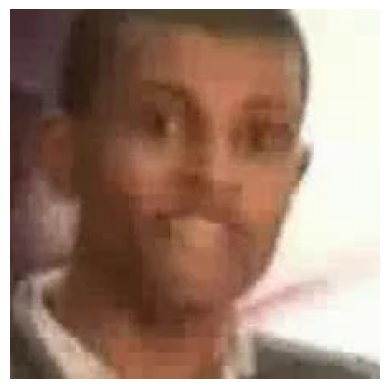

In [2]:
import cv2
import matplotlib.pyplot as plt

sample_vid = videos[0]

capture = cv2.VideoCapture(str(sample_vid))

if not capture.isOpened():
    print("Error: Video has not been opened")
print(f"FPS: {capture.get(cv2.CAP_PROP_FPS)}")
print(f"Frame Count: {capture.get(cv2.CAP_PROP_FRAME_COUNT)}")
print(f"Width: {capture.get(cv2.CAP_PROP_FRAME_WIDTH)}")
print(f"Height: {capture.get(cv2.CAP_PROP_FRAME_HEIGHT)}")


ret, frame = capture.read()
capture.release()

print(f"First frame loaded: {ret}")
if ret:
    print(f"Frame shape: {frame.shape}")

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.show()

   

In [10]:
import pandas as pd
import tqdm

def frame_check(videos):
    rows = []
    failed_count = 0
    
    for video in tqdm.tqdm(videos, desc="Checking videos", unit="video"):
        capture = cv2.VideoCapture(str(video))
    
        opened = capture.isOpened()
        
        fps = capture.get(cv2.CAP_PROP_FPS) if opened else None
        frame_count = capture.get(cv2.CAP_PROP_FRAME_COUNT) if opened else None
        width = capture.get(cv2.CAP_PROP_FRAME_WIDTH) if opened else None
        height = capture.get(cv2.CAP_PROP_FRAME_HEIGHT) if opened else None
    
        ret, frame = capture.read() if opened else (False, None)
        capture.release()
        
        rows.append({
            "path": str(video),
            "opened": opened,
            "fps": fps,
            "frame_count": frame_count,
            "width": width,
            "height": height,
            "first_frame_loaded": ret,    
        })

        if not ret:
            failed_count += 1
            tqdm.write(
                f"Frame not loaded: {path} "
                f"(failed count: {failed_count})"
            )

    if failed_count == 0:
        print("All first frames for all videos were successfully loaded")
        
    df = pd.DataFrame(rows)

    return df 
    
frame_check(videos)

Checking videos: 100%|██████████| 77326/77326 [12:41<00:00, 101.56video/s]


All first frames for all videos were successfully loaded


,path,opened,fps,frame_count,width,height,first_frame_loaded
0,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,True,25.0,453.0,224.0,224.0,True
1,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,True,25.0,450.0,224.0,224.0,True
2,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,True,25.0,451.0,224.0,224.0,True
3,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,True,25.0,453.0,224.0,224.0,True
4,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,True,25.0,1262.0,224.0,224.0,True
...,...,...,...,...,...,...,...
77321,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,True,25.0,153.0,224.0,224.0,True
77322,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,True,25.0,223.0,224.0,224.0,True
77323,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,True,25.0,223.0,224.0,224.0,True
77324,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,True,25.0,222.0,224.0,224.0,True


Frames shape: (8, 224, 224, 3)


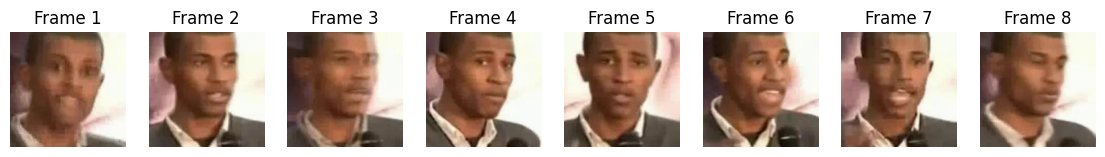

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def sample_frames(video_path, num_frames=8, resize=(224, 224)):
    """
    Open a video, sample a fixed number of frames evenly across it,
    resize them, and return them as RGB numpy arrays.

    Output shape:
    (num_frames, height, width, channels)
    """
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        raise ValueError(f"Video has no readable frames: {video_path}")

    frame_indices = np.linspace(0, total_frames - 1, num_frames).astype(int)

    frames = []

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()

        if not ret:
            continue

        # OpenCV gives BGR, but most ML/plotting tools expect RGB
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, resize)

        frames.append(frame)

    cap.release()

    return np.array(frames)


sample_video = videos[0]
frames = sample_frames(sample_video, num_frames=8)

print("Frames shape:", frames.shape)
plt.figure(figsize=(14, 4))

for i, frame in enumerate(frames):
    plt.subplot(1, len(frames), i + 1)
    plt.imshow(frame)
    plt.axis("off")
    plt.title(f"Frame {i+1}")

plt.show()

In [30]:
from pathlib import Path
import subprocess

AUDIO_DEBUG_DIR = DATA_DIR / "audio_debug"
AUDIO_DEBUG_DIR.mkdir(parents=True, exist_ok=True)

audio_out = AUDIO_DEBUG_DIR / "sample_audio_fixed.wav"

cmd = [
    "ffmpeg",
    "-y",
    "-i", str(sample_video),
    "-map", "0:a:0",
    "-t", "5",
    "-ac", "1",
    "-ar", "16000",
    "-acodec", "pcm_s16le",
    str(audio_out)
]

process = subprocess.run(cmd, capture_output=True, text=True)

print("Return code:", process.returncode)
print(process.stderr[-2000:])

print("Exists:", audio_out.exists())
if audio_out.exists():
    print("Size bytes:", audio_out.stat().st_size)

Return code: 0
ibwebp --enable-ffplay --enable-vulkan --enable-libshaderc --pkg-config=/home/conda/feedstock_root/build_artifacts/ffmpeg_1783096298666/_build_env/bin/pkg-config
  libavutil      60. 26.102 / 60. 26.102
  libavcodec     62. 28.102 / 62. 28.102
  libavformat    62. 12.102 / 62. 12.102
  libavdevice    62.  3.102 / 62.  3.102
  libavfilter    11. 14.102 / 11. 14.102
  libswscale      9.  5.102 /  9.  5.102
  libswresample   6.  3.102 /  6.  3.102
[aist#0:1/pcm_s16le @ 0x55eb5cd5b280] Guessed Channel Layout: mono
Input #0, mov,mp4,m4a,3gp,3g2,mj2, from '/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/extracted/val/val/lrs3/1Hok1iGFNSk/00004/fake_video_fake_audio.mp4':
  Metadata:
    major_brand     : isom
    minor_version   : 512
    compatible_brands: isomiso2avc1mp41
    encoder         : Lavf60.16.100
  Duration: 00:00:18.18, start: 0.000000, bitrate: 670 kb/s
  Stream #0:0[0x1](und): Video: h264 (High) (avc1 / 0x31637661), yuv420p(progressive), 224x224, 412 kb/s, 25 fps,

In [31]:
import wave

with wave.open(str(audio_out), "rb") as wav:
    print("Channels:", wav.getnchannels())
    print("Sample rate:", wav.getframerate())
    print("Frames:", wav.getnframes())
    print("Duration:", wav.getnframes() / wav.getframerate())

Channels: 1
Sample rate: 16000
Frames: 80000
Duration: 5.0
